<a href="https://colab.research.google.com/github/Sharuna-Ahamath/AI-in-healthcare-portfolio/blob/main/Week_6_AI_practical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)


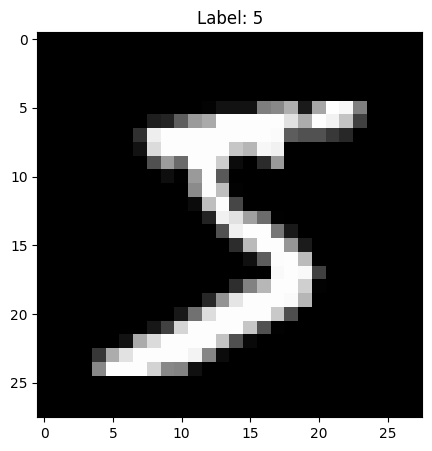

The raw pixel values (0-255):
[[  0   0   0   0   0]
 [  0   0   0  30  36]
 [  0   0  49 238 253]
 [  0   0  18 219 253]
 [  0   0   0  80 156]]


In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load the classic MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Training Data Shape: {X_train.shape}") # (60000, 28, 28)

# Let's see what the computer sees
plt.figure(figsize=(5,5))
plt.imshow(X_train[0], cmap='gray')
plt.title(f"Label: {y_train [0]}")
plt.show()

# Show the raw grid of numbers
print("The raw pixel values (0-255):")
print(X_train[0] [5:10, 5:10]) # Peek at a slice

In [2]:
# 1. Scaling: Convert from 0-255 to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

# 2. Flattening is handled inside the model in Keras

In [5]:
from tensorflow.keras import layers, models

model = models. Sequential( [
# Input Layer: Flattens 28x28 image into 784 pixels
layers.Flatten(input_shape=(28, 28)),

# Hidden Layer 1: 128 Neurons, ReLU activation (The thinking part)
layers.Dense(128, activation='relu'),

# Hidden Layer 2: 64 Neurons (More thinking)
layers.Dense(64, activation='relu'),

# Output Layer: 10 Neurons (one for each digit 0-9), Softmax (Probability)
layers.Dense(10, activation='softmax' )
])
model. summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model. compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'] )

# Train the model
# Epochs = How many times we go through the whole textbook
history = model. fit(X_train, y_train, epochs=5, validation_split=0.1)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8737 - loss: 0.4330 - val_accuracy: 0.9650 - val_loss: 0.1170
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9663 - loss: 0.1123 - val_accuracy: 0.9685 - val_loss: 0.1005
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9764 - loss: 0.0749 - val_accuracy: 0.9748 - val_loss: 0.0856
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9822 - loss: 0.0564 - val_accuracy: 0.9763 - val_loss: 0.0885
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9872 - loss: 0.0404 - val_accuracy: 0.9793 - val_loss: 0.0810


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9692 - loss: 0.0997

Test Accuracy: 97.39%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


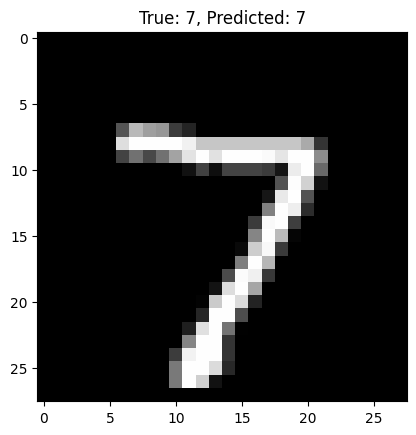

In [8]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_acc*100 :.2f}%")

# Make a prediction
predictions = model.predict (X_test)

# Let's look at the first image in the test set
plt.imshow(X_test[0], cmap='gray')
plt.title(f"True: {y_test[0]}, Predicted: {np.argmax(predictions[0])}")
plt.show()

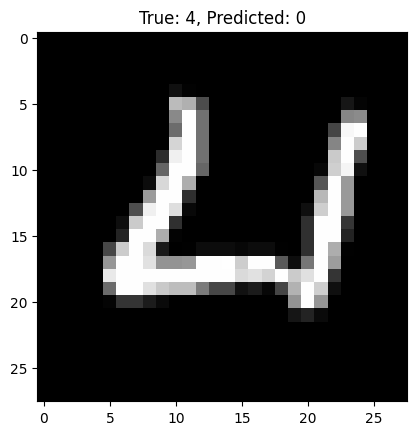

In [9]:
# Find indices where prediction != actual
predicted_labels = np.argmax(predictions, axis=1)
wrong_indices = np.where(predicted_labels != y_test) [0]

# Plot the first mistake
idx = wrong_indices [0]
plt.imshow(X_test[idx], cmap='gray')
plt.title(f"True: {y_test[idx]}, Predicted: {predicted_labels[idx] }")
plt.show( )